# Visualisation de l'évolution du modèle sous drift

On génère un **GIF animé** + des **images séquentielles** montrant l'évolution des **neurones d'ancrage** pendant l'entraînement en drift (0/1 puis 2-9 avec élagage Physarum).

Chaque frame montre une **grille de 20 prototypes de neurones** (régénérés par rétro-projection des poids) avec leur **classe dominante** et leur **flux d'activation**, plus l'**acc globale** courante.

## 0. Imports

In [1]:
# Visualisation de l'évolution du modèle drift (GIF + frames)
import os
import io
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from PIL import Image
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k)

## 1. Données + helpers

In [2]:
train_set, test_set = load_mnist()
os.makedirs('figs', exist_ok=True)

def latent(img_np):
    img = img_np.flatten()
    return img / (np.linalg.norm(img) + 1e-8)

def accuracy_global(anchors, n=150):
    rng = np.random.default_rng(42)
    idx = rng.choice(len(test_set), size=n, replace=False)
    correct = total = 0
    for i in idx:
        l = int(test_set[i][1])
        pred, _ = anchors.predict_label(latent(test_set[i][0].squeeze().numpy()))
        if pred is not None:
            total += 1
            if pred == l: correct += 1
    return correct/total if total else 0

def neuron_prototype(anchors, n_idx):
    w = anchors.W[n_idx]
    img = w.reshape(28, 28)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def make_frame(anchors, label, acc):
    fig, axes = plt.subplots(4, 5, figsize=(12, 10))
    fig.suptitle(f"{label} | acc globale={acc:.2f}", fontsize=14)
    order = np.argsort(-anchors.activations)[:20]
    for k, n_idx in enumerate(order):
        ax = axes[k//5, k%5]
        ax.imshow(neuron_prototype(anchors, n_idx), cmap='gray')
        cls = anchors.labels_seen.get(n_idx, {})
        if cls:
            dom = max(cls.items(), key=lambda x: x[1])[0]
            ax.set_title(f"n{n_idx}→{dom} (flx {anchors.activations[n_idx]:.0f})", fontsize=7)
        else:
            ax.set_title(f"n{n_idx} (libre)", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png'); plt.close(fig)
    buf.seek(0)
    return np.array(Image.open(buf).convert('RGB'))

## 2. Protocole drift avec snapshots + GIF

In [3]:
anchors = AnchorNeurons(d_in=784, n_neurons=200, seed=0, lr=0.1, use_homeostasis=True)
frames = []

# Phase 1 : 0/1 progressif avec snapshots
cnt = [0]*10; presented = 0
snapshot_targets = [50, 150, 400]; si = 0
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if l > 1 or cnt[l] >= 200: continue
    anchors.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
    cnt[l] += 1; presented += 1
    if si < len(snapshot_targets) and presented >= snapshot_targets[si]:
        frames.append(make_frame(anchors, f"Phase 1 : 0/1 ({presented} img)", accuracy_global(anchors)))
        si += 1
    if sum(cnt[:2]) >= 400: break

# Phase 2 : 2-9 avec élagage Physarum
for new_digit in range(2, 10):
    shown = 0
    for i in range(len(train_set)):
        l = int(train_set[i][1])
        if l != new_digit: continue
        anchors.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
        shown += 1
        if shown >= 60: break
    anchors.physarum_prune(0.2)
    frames.append(make_frame(anchors, f"Phase 2 : après intro {new_digit}", accuracy_global(anchors)))

print(f"Frames générées : {len(frames)}")

# Sauver frames individuelles
for i, f in enumerate(frames):
    imageio.imwrite(f'figs/drift_frame_{i:02d}.png', f)

# GIF animé
imageio.mimsave('figs/drift_evolution.gif', frames, duration=0.8)
print("GIF : figs/drift_evolution.gif")

Frames générées : 11


GIF : figs/drift_evolution.gif


## 3. Afficher quelques frames clés

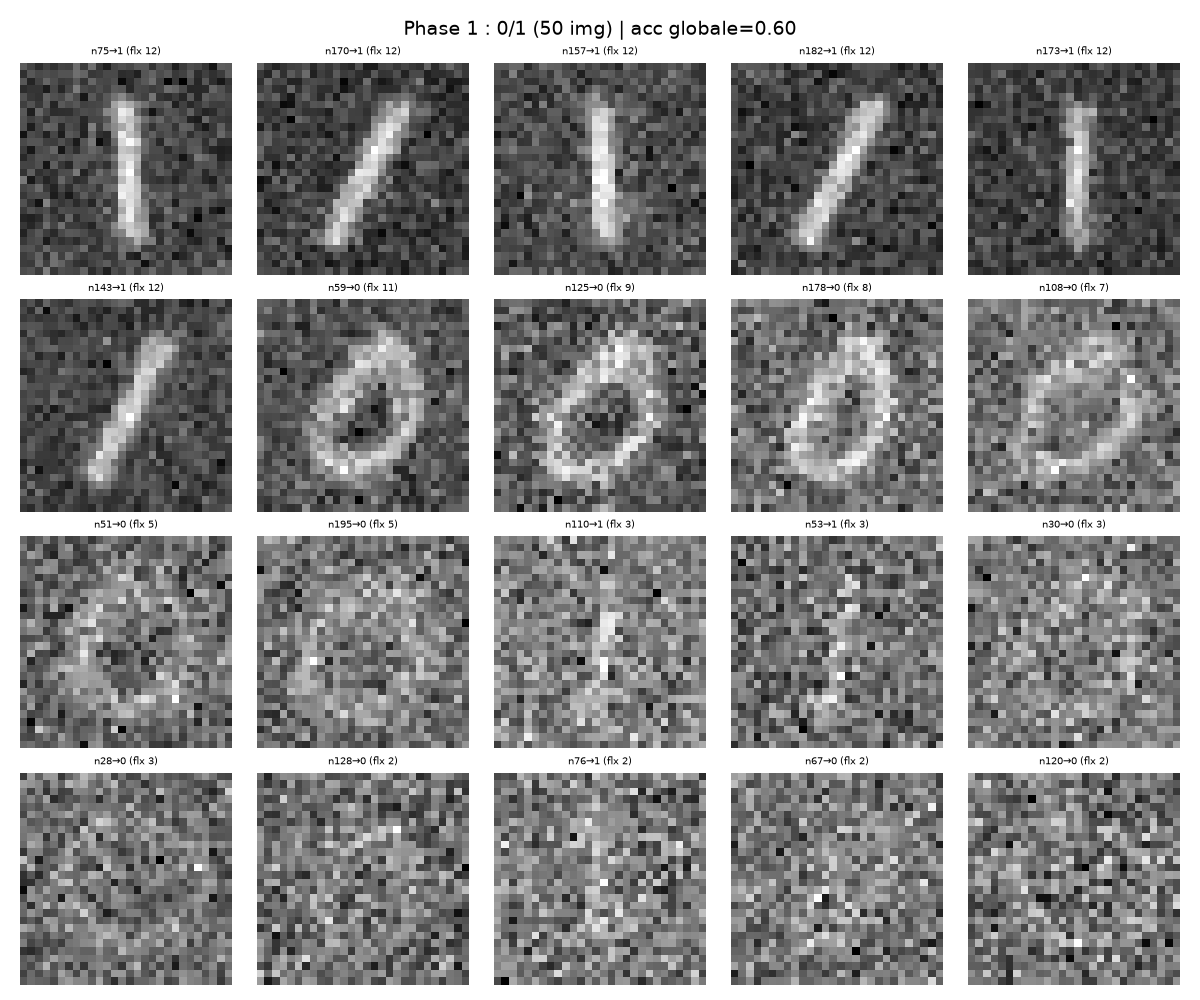

--- Frame 1/11 ---


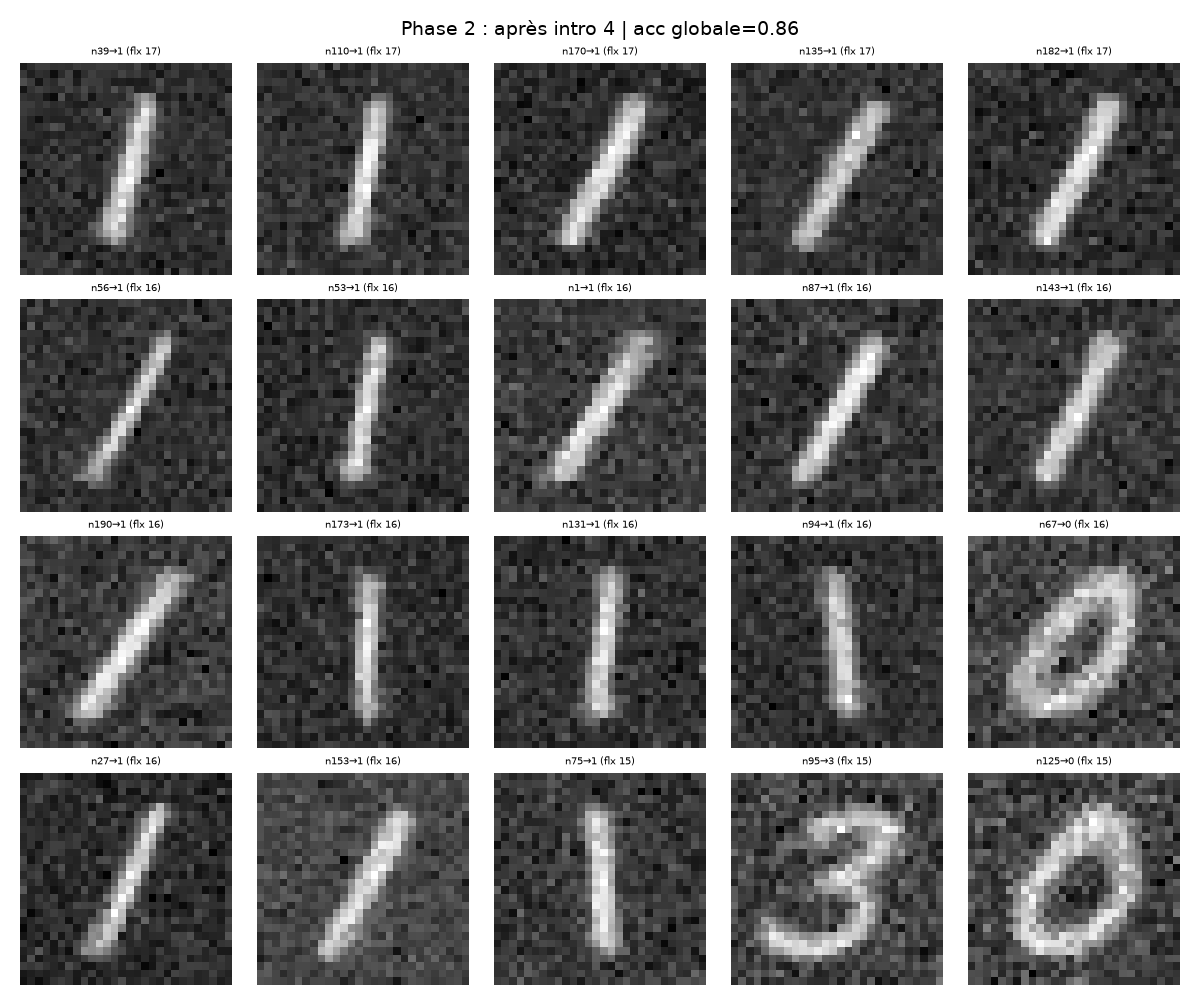

--- Frame 6/11 ---


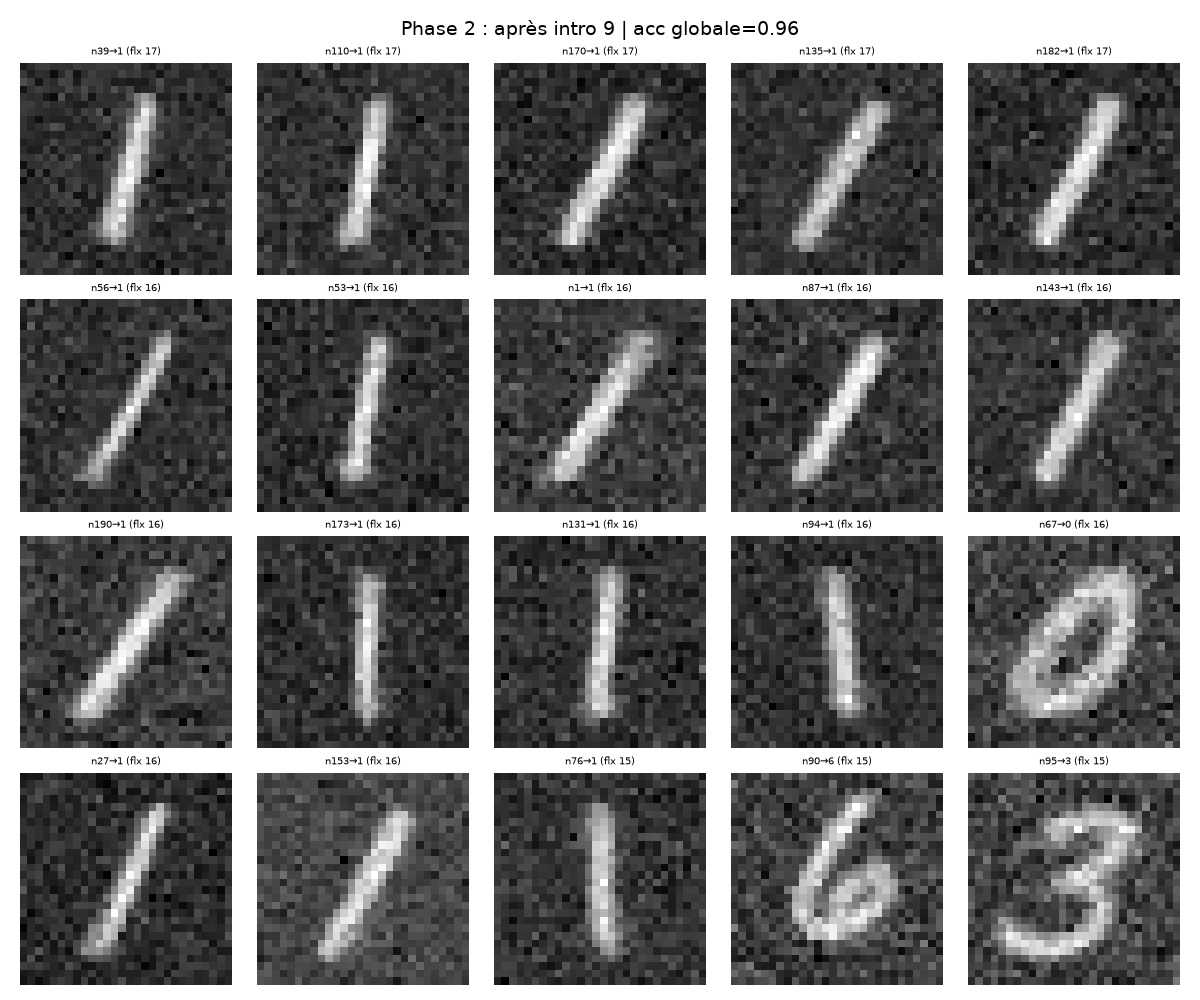

--- Frame 11/11 ---


In [4]:
# Montrer 3 frames : début 0/1, mi-drift, fin
from IPython.display import Image as IPImage
for idx in [0, len(frames)//2, len(frames)-1]:
    display(IPImage(filename=f'figs/drift_frame_{idx:02d}.png'))
    print(f"--- Frame {idx+1}/{len(frames)} ---")

## 4. Le GIF animé

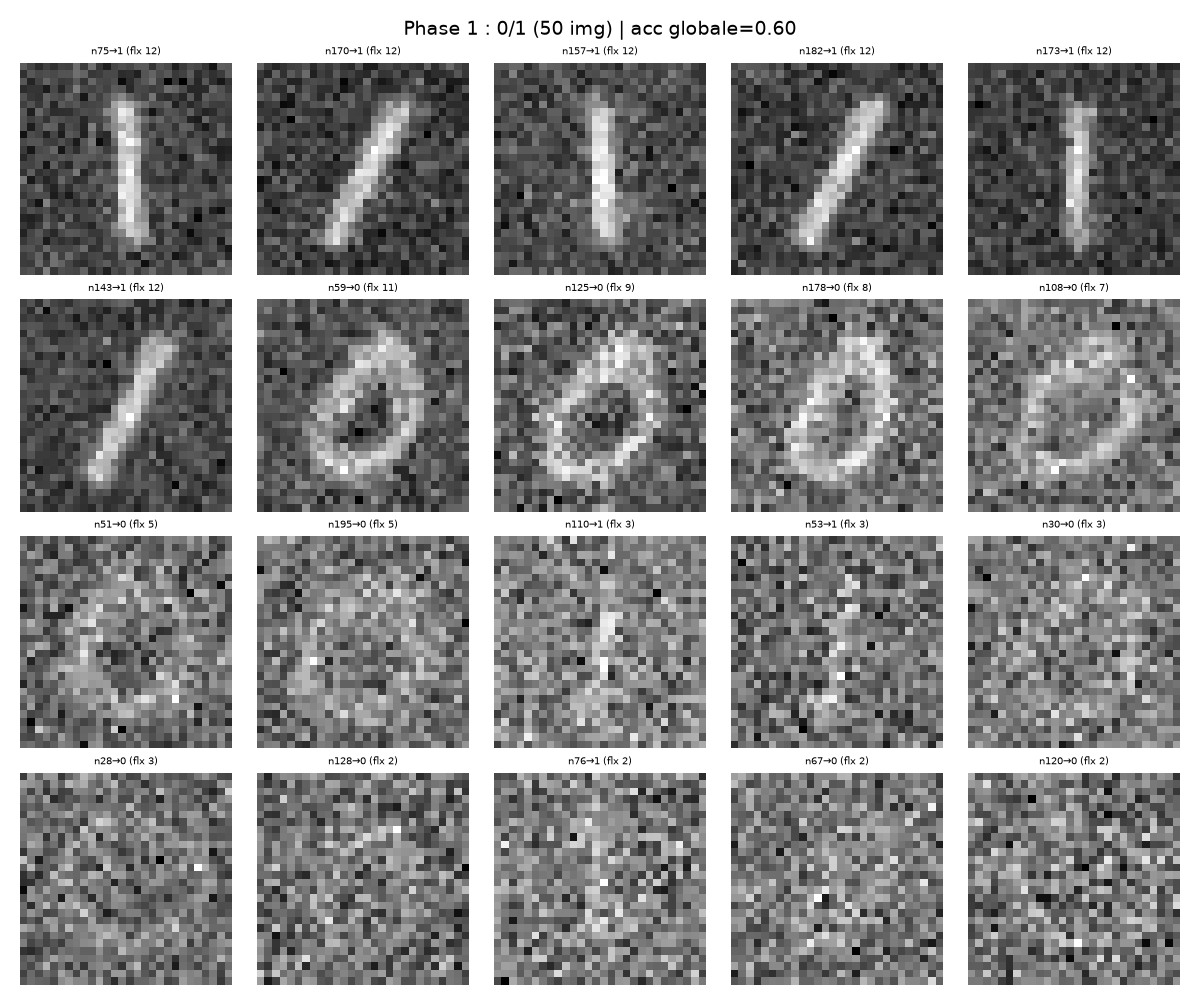

In [5]:
# Afficher le GIF (boucle)
from IPython.display import Image as IPImage
display(IPImage(filename='figs/drift_evolution.gif'))